## make_bry:
### Make lateral boundary conditions, using salt and temp from ECCO2
### Interannual forcing
#### Version id:
#### v1.
#### v2. Updated IAF code. Added nanning of e-34 salt;

In [1]:
cd /g/data/jk72/deg581/amundsen-isom/amundsen-setup/notebooks

/g/data/jk72/deg581/amundsen-isom/amundsen-setup/notebooks


In [2]:
run = 'amundsen_v2.5km'
anything_else='_v1.2'


import xarray as xr
# from netCDF4 import Dataset
import numpy as np 
from scipy.interpolate import RegularGridInterpolator
from scipy.interpolate import NearestNDInterpolator
# from scipy.interpolate import LinearNDInterpolator
# from scipy.interpolate import CloughTocher2DInterpolator
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import datetime
from dask.diagnostics import ProgressBar
ProgressBar().register()

proj_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
data_dir = os.path.join(proj_dir,'data')
src_dir = os.path.join(proj_dir,'src')

sys.path.append(src_dir)

from ext.tools.calc_z import calc_z as calc_z_old
try: 
    from functions import GridStiffness
except:
    print('couldn''t load')

from functions import GridStiffness


# Time settings for IAF
year_start =  1992
year_end = 2024 # run from year_start up to the beginning of year year_end

if_cycle365 = True # cycle just the single year over 365 days. Also pre/post-pend the last/first value.
cycle=365.0

# set user parameter and call main routine
grd_file = os.path.join(data_dir,'proc','amundsen_2.5km_v1.2_grd.nc')

import socket
comp_name = socket.gethostname()
if comp_name=='SEES-3PV4VV3':
    # data_dir = os.path.join('/g/data/jk72/iomp/obs/ecco2_cube92_monthly/ECCO2/cube92_latlon_quart_90S90N/monthly/')
    # Path to ECCO2 files for temperature and salinity, uvel and vvel
    salt_file = os.path.join(data_dir,'SALT/')
    theta_file = os.path.join(data_dir,'THETA/')
    uvel_file = os.path.join(data_dir,'UVEL/')
    vvel_file = os.path.join(data_dir,'VVEL/')
else:
     # data_dir = os.path.join('/g/data/gi0/iomp/ECCO2_cube92_monthly/')
    data_dir_ext = os.path.join('/g/data/jk72/iomp/obs/ecco2_cube92_monthly/ECCO2/cube92_latlon_quart_90S90N/monthly/')
    # Path to ECCO2 files for temperature and salinity, uvel and vvel
    salt_file = os.path.join(data_dir_ext,'SALT/')
    theta_file = os.path.join(data_dir_ext,'THETA/')
    uvel_file = os.path.join(data_dir_ext,'UVEL/')
    vvel_file = os.path.join(data_dir_ext,'VVEL/')





# Grid parameters; check grid_file and *.in file to make sure these are correct
N=31
Vtransform=2
Vstretching=4
theta_s=0.8
theta_b=3
Tcline=50
hc=Tcline # if Vtransform==2, hc=Tcline

# southernmost index of ECCO2 grid to read (1-based)
nbdry_ecco = 300

# upper and lower bounds for temp and salinity
tempUp = 10
tempLow = -3

saltUp = 34.8
saltLow = 33.2

In [3]:
# define inpaint_nans

def inpaint_nans(inField):
    im = inField.copy()
    import scipy
    ipn_kernel = np.array([[1,1,1],[1,0,1],[1,1,1]]) # kernel for inpaint_nans
    nans = np.isnan(im)
    while np.sum(nans)>0:
        im[nans] = 0
        vNeighbors = scipy.signal.convolve2d((nans==False),ipn_kernel,mode='same',boundary='symm')
        im2 = scipy.signal.convolve2d(im,ipn_kernel,mode='same',boundary='symm')
        im2[vNeighbors>0] = im2[vNeighbors>0]/vNeighbors[vNeighbors>0]
        im2[vNeighbors==0] = np.nan
        im2[(nans==False)] = im[(nans==False)]
        im = im2
        nans = np.isnan(im)
    return im

In [4]:
grd = xr.open_dataset(grd_file)
print(grd.lon_rho.min().values, grd.lon_rho.max().values,grd.lat_rho.min().values, grd.lat_rho.max().values)

print('noting that ecco2 data ranges lons 0 to 360...')

print(grd.lon_rho.min().values % 360, grd.lon_rho.max().values % 360,grd.lat_rho.min().values % 360, grd.lat_rho.max().values % 360)


-140.04999998171326 -89.94999998824356 -76.0874999918504 -68.9124999881915
noting that ecco2 data ranges lons 0 to 360...
219.95000001828674 270.0500000117564 283.9125000081496 291.0875000118085


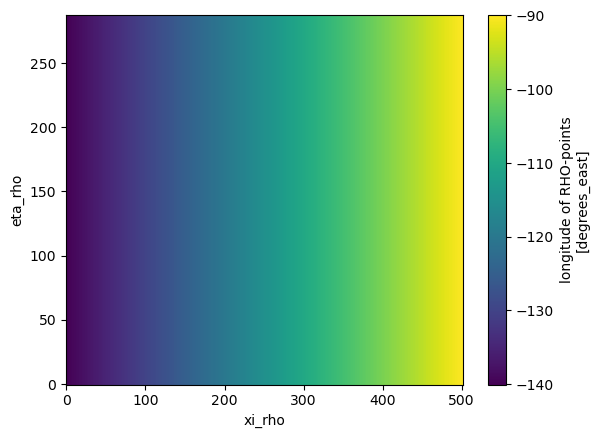

In [5]:
(grd.lon_rho).plot()

In [6]:
# make the interpolation surfaces for the input grid. First use the old style indexing method
z_rho_3d, sc_r, Cs_r = calc_z_old(grd.h, grd.zice, theta_s, theta_b, hc, N)
lon_rho_3d = np.tile(grd.lon_rho, (N,1,1))
lat_rho_3d = np.tile(grd.lat_rho, (N,1,1))

# join together L,T,R,B
# don't flip the R,B faces as ROMS expects to reads from the i/j=1 position outwards.
DepthsInterpSurface = np.concatenate((z_rho_3d[:,:,0],z_rho_3d[:,-1,:],z_rho_3d[:,:,-1],z_rho_3d[:,0,:]),axis=1)
LatInterpSurface = np.concatenate((lat_rho_3d[:,:,0],lat_rho_3d[:,-1,:],lat_rho_3d[:,:,-1],lat_rho_3d[:,0,:]),axis=1)
LonInterpSurface = np.concatenate((lon_rho_3d[:,:,0],lon_rho_3d[:,-1,:],lon_rho_3d[:,:,-1],lon_rho_3d[:,0,:]),axis=1) 

In [7]:
if LonInterpSurface.min() < 0:
    print('WARNING: VALUES BELOW 0, need to wrap longitude around by +360')
    LonInterpSurface = LonInterpSurface % 360

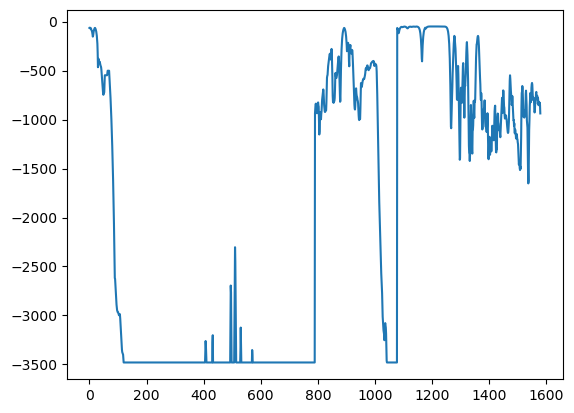

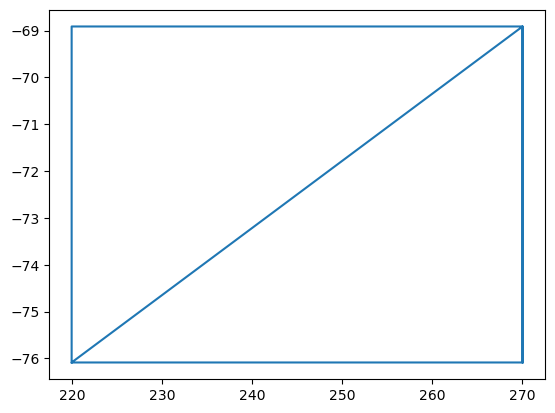

In [8]:
plt.plot(DepthsInterpSurface[0,:])
plt.show()
plt.plot(LonInterpSurface[0,:],LatInterpSurface[0,:])


1992
/g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/proc/amundsen_v2.5km_1992_v1.2_cycle365_bry.nc
load and subset data
[########################################] | 100% Completed | 1.92 ss


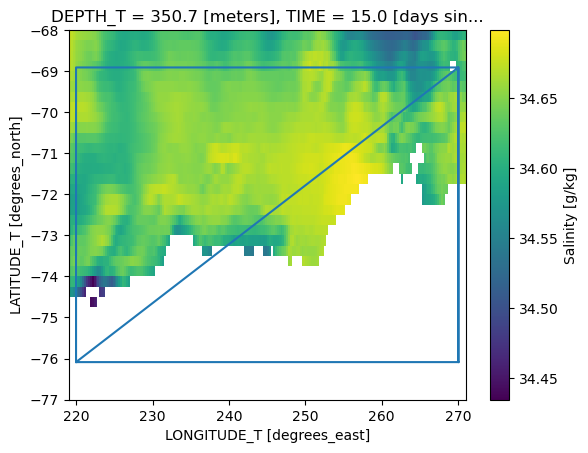

interpolating fields
processing time value:  0
[########################################] | 100% Completed | 842.48 ms
[########################################] | 100% Completed | 1.01 ss
[########################################] | 100% Completed | 1.01 ss
[########################################] | 100% Completed | 1.52 ss
processing time value:  1
[########################################] | 100% Completed | 914.03 ms
[########################################] | 100% Completed | 1.01 ss
[########################################] | 100% Completed | 1.11 ss
[########################################] | 100% Completed | 1.32 ss
processing time value:  2
[########################################] | 100% Completed | 2.13 ss
[########################################] | 100% Completed | 1.01 ss
[########################################] | 100% Completed | 2.53 ss
[########################################] | 100% Completed | 1.11 ss
processing time value:  3
[##############################

In [9]:
for working_year in range(year_start,1993):
    print(working_year)
    if if_cycle365:
        anything_else = anything_else+'_cycle365'
    out_file = os.path.join(data_dir,'proc',run+'_'+str(working_year)+anything_else+'_bry.nc')
    print(out_file)

    print('load and subset data')
    # load data
    salt_full = xr.open_mfdataset(salt_file+'SALT.1440x720x50.'+str(working_year)+'*.nc',decode_times=False)
    theta_full = xr.open_mfdataset(theta_file+'THETA.1440x720x50.'+str(working_year)+'*.nc',decode_times=False)
    uvel_full = xr.open_mfdataset(uvel_file+'UVEL.1440x720x50.'+str(working_year)+'*.nc',decode_times=False)
    vvel_full = xr.open_mfdataset(vvel_file+'VVEL.1440x720x50.'+str(working_year)+'*.nc',decode_times=False)

    # subset data
    lon_rho_max = (grd.lon_rho.max().values+1) % 360
    lon_rho_min = (grd.lon_rho.min().values-1) % 360
    lat_rho_max = grd.lat_rho.max().values+1
    lat_rho_min = grd.lat_rho.min().values-1

    
    salt = salt_full.sel(LATITUDE_T=slice(lat_rho_min,lat_rho_max),LONGITUDE_T=slice(lon_rho_min,lon_rho_max))
    theta = theta_full.sel(LATITUDE_T=slice(lat_rho_min,lat_rho_max),LONGITUDE_T=slice(lon_rho_min,lon_rho_max))
    uvel = uvel_full.sel(LATITUDE_T=slice(lat_rho_min,lat_rho_max),LONGITUDE_T=slice(lon_rho_min,lon_rho_max))
    vvel = vvel_full.sel(LATITUDE_T=slice(lat_rho_min,lat_rho_max),LONGITUDE_T=slice(lon_rho_min,lon_rho_max))
    salt.SALT.isel(TIME=0,DEPTH_T=20).plot()
    plt.plot(LonInterpSurface[0,:],LatInterpSurface[0,:])
    plt.show()
    
    # make array in preparation, with time length

    salt_i = np.full((*salt_full.TIME.shape,*LonInterpSurface.shape),np.nan)
    theta_i = np.full((*theta_full.TIME.shape,*LonInterpSurface.shape),np.nan)
    uvel_i = np.full((*uvel_full.TIME.shape,*LonInterpSurface.shape),np.nan)
    vvel_i = np.full((*vvel_full.TIME.shape,*LonInterpSurface.shape),np.nan)
    
    # remove the -1e23 values by replacing with a np.nan
    salt['SALT'] = salt.SALT.where(salt.SALT != -1e23, np.nan)
    theta['THETA'] = theta.THETA.where(theta.THETA != -1e23, np.nan)
    uvel['UVEL'] = uvel.UVEL.where(uvel.UVEL != -1e23, np.nan)
    vvel['VVEL'] = vvel.VVEL.where(vvel.VVEL != -1e23, np.nan)

    print('interpolating fields')
    # start time loop and interpolate values to new locations
    for tt in range(len(salt_full.TIME)):
        print('processing time value: ',tt)
        # make the interpolator for each time point
        interp_function_salt = RegularGridInterpolator((salt.LONGITUDE_T.values, salt.LATITUDE_T.values, salt.DEPTH_T.values ), np.transpose(salt.SALT.isel(TIME=tt).values,(2,1,0)), method='linear', bounds_error=False, fill_value=np.nan)
        interp_function_theta = RegularGridInterpolator((theta.LONGITUDE_T.values, theta.LATITUDE_T.values, theta.DEPTH_T.values ), np.transpose(theta.THETA.isel(TIME=tt).values,(2,1,0)), method='linear', bounds_error=False, fill_value=np.nan)
        interp_function_uvel = RegularGridInterpolator((salt.LONGITUDE_T.values, salt.LATITUDE_T.values, salt.DEPTH_T.values ), np.transpose(uvel.UVEL.isel(TIME=tt).values,(2,1,0)), method='linear', bounds_error=False, fill_value=np.nan)
        interp_function_vvel = RegularGridInterpolator((theta.LONGITUDE_T.values, theta.LATITUDE_T.values, theta.DEPTH_T.values ), np.transpose(vvel.VVEL.isel(TIME=tt).values,(2,1,0)), method='linear', bounds_error=False, fill_value=np.nan)

        salt_i[tt,:,:] = interp_function_salt((LonInterpSurface, LatInterpSurface, -DepthsInterpSurface))
        theta_i[tt,:,:] = interp_function_theta((LonInterpSurface, LatInterpSurface, -DepthsInterpSurface))
        uvel_i[tt,:,:] = interp_function_uvel((LonInterpSurface, LatInterpSurface, -DepthsInterpSurface))
        vvel_i[tt,:,:] = interp_function_vvel((LonInterpSurface, LatInterpSurface, -DepthsInterpSurface))

            
        # replace the -1e23 values with nans
        salt_i[tt,:,:][(salt_i[tt,:,:] > 100) & (salt_i[tt,:,:] < -100)] = np.nan
        theta_i[tt,:,:][(theta_i[tt,:,:] > 100) & (theta_i[tt,:,:] < -100)] = np.nan
        uvel_i[tt,:,:][(uvel_i[tt,:,:] > 100) & (uvel_i[tt,:,:] < -100)] = np.nan
        vvel_i[tt,:,:][(vvel_i[tt,:,:] > 100) & (vvel_i[tt,:,:] < -100)] = np.nan

        salt_i[tt,:,:] = inpaint_nans(salt_i[tt,:,:])
        theta_i[tt,:,:] = inpaint_nans(theta_i[tt,:,:])
        uvel_i[tt,:,:] = inpaint_nans(uvel_i[tt,:,:])
        vvel_i[tt,:,:] = inpaint_nans(vvel_i[tt,:,:])
        # if tt==0: #DEBUG
        #     plt.pcolormesh(salt_i[tt,:,:])#,vmin=33,vmax=35)
        #     plt.colorbar()
        #     plt.show()
         
    # make the zeta variable. For now set it to zeros
    zeta_i = np.zeros_like(salt_i[:,0,:])
    
    print('separating velocities')
    # separate out theta, salt, uvvel, vvel 

    # left or "WEST"
    # SET TO 0 FOR NOW - TO UPDATE IN TIME.
    select=slice(0,z_rho_3d.shape[1])
    salt_west = salt_i[:,:,select]
    temp_west = theta_i[:,:,select]
    u_west = uvel_i[:,:,select]
    v_west = vvel_i[:,:,select]
    # ubar_west = np.zeros(uvel_i[:,:,select].shape)
    # vbar_west = np.zeros(vvel_i[:,:,select].shape)
    zeta_west = zeta_i[:,select]

    # top or "NORTH"
    select=slice(z_rho_3d.shape[1],z_rho_3d.shape[1]+z_rho_3d.shape[2])
    salt_north = salt_i[:,:,select]
    temp_north = theta_i[:,:,select]
    u_north = uvel_i[:,:,select]
    v_north = vvel_i[:,:,select]
    # ubar_north = np.zeros(uvel_i[:,:,select].shape)
    # vbar_north = np.zeros(vvel_i[:,:,select].shape)
    zeta_north = zeta_i[:,select]

    # right or "EAST"
    select=slice(z_rho_3d.shape[1]+z_rho_3d.shape[2],z_rho_3d.shape[1]+z_rho_3d.shape[2]+z_rho_3d.shape[1])
    temp_east = theta_i[:,:,select]
    salt_east = salt_i[:,:,select]
    u_east = uvel_i[:,:,select]
    v_east = vvel_i[:,:,select]
    # ubar_east = np.zeros(uvel_i[:,:,select].shape)
    # vbar_east = np.zeros(vvel_i[:,:,select].shape)
    zeta_east = zeta_i[:,select]

    # bottom or "SOUTH"
    select=slice(z_rho_3d.shape[1]+z_rho_3d.shape[2]+z_rho_3d.shape[1],z_rho_3d.shape[1]+z_rho_3d.shape[2]+z_rho_3d.shape[1]+z_rho_3d.shape[2])
    temp_south = theta_i[:,:,select]
    salt_south = salt_i[:,:,select]
    u_south = uvel_i[:,:,select]
    v_south = vvel_i[:,:,select]
    # ubar_south = np.zeros(uvel_i[:,:,select].shape)
    # vbar_south = np.zeros(vvel_i[:,:,select].shape)
    zeta_south = zeta_i[:,select]

    print('rotate angles')
    # Now rotate angles!
    angle3 = np.tile(grd.angle, (len(salt_full.TIME), N,1,1))

    angle_south = angle3[:,:,0,:]
    u_south_unrot = u_south.copy()
    v_south_unrot = v_south.copy()
    u_south_latlon =  u_south.copy()
    v_south_latlon =  v_south.copy()
    uv_south = (u_south_latlon + 1j*v_south_latlon) * np.exp(-1j*angle_south)
    u_south_rho = uv_south.real
    v_south = uv_south.imag
    u_south = 0.5 * (u_south_rho[:,:,0:-1]+u_south_rho[:,:,1:])

    angle_east = angle3[:,:,:,-1]
    u_east_unrot = u_east.copy()
    v_east_unrot = v_east.copy()
    u_east_latlon =  u_east.copy()
    v_east_latlon =  v_east.copy()
    uv_east = (u_east_latlon + 1j*v_east_latlon) * np.exp(-1j*angle_east)
    u_east = uv_east.real
    v_east_rho = uv_east.imag
    v_east = 0.5 * (v_east_rho[:,:,0:-1]+v_east_rho[:,:,1:])

    angle_north = angle3[:,:,-1,:]
    u_north_unrot = u_north.copy()
    v_north_unrot = v_north.copy()
    u_north_latlon =  u_north.copy()
    v_north_latlon =  v_north.copy()
    uv_north = (u_north_latlon + 1j*v_north_latlon) * np.exp(-1j*angle_north)
    u_north_rho = uv_north.real
    v_north = uv_north.imag
    u_north = 0.5 * (u_north_rho[:,:,0:-1]+u_north_rho[:,:,1:])

    angle_west = angle3[:,:,:,0]
    u_west_unrot = u_west.copy()
    v_west_unrot = v_west.copy()
    u_west_latlon =  u_west.copy()
    v_west_latlon =  v_west.copy()
    uv_west = (u_west_latlon + 1j*v_west_latlon) * np.exp(-1j*angle_west)
    u_west = uv_west.real
    v_west_rho = uv_west.imag
    v_west = 0.5 * (v_west_rho[:,:,0:-1]+v_west_rho[:,:,1:])
    
    print('make ubar and vbar depth averaged velocities')
    
    #calculate mapping from u to ubar
    z_rho,z_w,=GridStiffness.calc_z(Vtransform,Vstretching,theta_s,theta_b,Tcline,hc,N,grd.h,grd.zice) # extract the z_w values

    # compute depth average velocity ubar and vbar
    # get z at the right position
    # based on: https://github.com/ESMG/pyroms/blob/5ea501ef904b01036dd2a0909b7bdc61a56e7eff/examples/Arctic_SODA3.3.1/remap_bdry_uv.py#L309
    z_u_north = 0.5 * (z_w[:,-1,:-1] + z_w[:,-1,1:]) # TOP: looks like my _east
    z_v_north = 0.5 * (z_w[:,-1,:] + z_w[:,-2,:])
    z_u_south = 0.5 * (z_w[:,0,:-1] + z_w[:,0,1:]) # BOTTOM: looks like my _west
    z_v_south = 0.5 * (z_w[:,0,:] + z_w[:,1,:])
    z_u_east = 0.5 * (z_w[:,:,-1] + z_w[:,:,-2]) # RIGHT: looks like my _north
    z_v_east = 0.5 * (z_w[:,:-1,-1] + z_w[:,1:,-1])
    z_u_west = 0.5 * (z_w[:,:,0] + z_w[:,:,1]) # LEFT: looks like my _south
    z_v_west = 0.5 * (z_w[:,:-1,0] + z_w[:,1:,0])
    # based on the averaging, this looks like pyroms expects:
    #        _north
    # 
    # _west         _east
    # 
    #        _south 

    ubar_north = np.zeros(u_north[:,0,:].shape)
    ubar_south = np.zeros(u_south[:,0,:].shape)
    ubar_east = np.zeros(u_east[:,0,:].shape)
    ubar_west = np.zeros(u_west[:,0,:].shape)
    vbar_north = np.zeros(v_north[:,0,:].shape)
    vbar_south = np.zeros(v_south[:,0,:].shape)
    vbar_east = np.zeros(v_east[:,0,:].shape)
    vbar_west = np.zeros(v_west[:,0,:].shape)

    for tt in range(len(salt_full.TIME)):
        print('processing time value: ',tt)

        for i in range(u_north[tt,:,:].shape[1]):
            ubar_north[tt,i] = (u_north[tt,:,i] * np.diff(z_u_north[:,i])).sum() / -z_u_north[0,i]
            ubar_south[tt,i] = (u_south[tt,:,i] * np.diff(z_u_south[:,i])).sum() / -z_u_south[0,i]
        for i in range(v_north[tt,:,:].shape[1]):
            vbar_north[tt,i] = (v_north[tt,:,i] * np.diff(z_v_north[:,i])).sum() / -z_v_north[0,i]
            vbar_south[tt,i] = (v_south[tt,:,i] * np.diff(z_v_south[:,i])).sum() / -z_v_south[0,i]
        for j in range(u_east[tt,:,:].shape[1]):
            ubar_east[tt,j] = (u_east[tt,:,j] * np.diff(z_u_east[:,j])).sum() / -z_u_east[0,j]
            ubar_west[tt,j] = (u_west[tt,:,j] * np.diff(z_u_west[:,j])).sum() / -z_u_west[0,j]
        for j in range(v_east[tt,:,:].shape[1]):
            vbar_east[tt,j] = (v_east[tt,:,j] * np.diff(z_v_east[:,j])).sum() / -z_v_east[0,j]
            vbar_west[tt,j] = (v_west[tt,:,j] * np.diff(z_v_west[:,j])).sum() / -z_v_west[0,j]
    
    
    # settings for making the netcdf file:
    time = np.arange((365/12/2),(365+365/12/2),365/12)+(working_year-year_start)*365 #time values for each data point (units of days)
    # cycle= float((year_end-year_start)*365) #365.0 #days over which to cycle the forcing data #ACTUALLY: remove cycle completely.
    
    print('check for nans')
    # check for nans and other bad values
    variables = ['theta_s','theta_b','Tcline','hc','sc_r','Cs_r','time']



    for arr_name in variables:
        arr = locals().get(arr_name)
        if arr is not None:
            if np.isnan(arr).any():
                print(f"Warning: NaN found in array '{arr_name}'")
            # else:
            #     print('no NaN in '+arr_name)
                
    #check for nans in all that boundary data

    boundary = ['_south','_east','_north','_west']
    variables = ['temp','salt','u','v','ubar','vbar']

    for bnd in boundary:
        for var in variables:
            arr_name = str(var+bnd)
            arr = locals().get(str(var+bnd))
            if arr is not None:
                if np.isnan(arr).any():
                    print(f"Warning: NaN found in array '{arr_name}'")
                # else:
                #     print('no NaN in '+arr_name)
                
    print('check sizes of fields')
    # quick of all field sizes
    boundary = ['_south','_east','_north','_west']
    variables = ['temp','salt','u','v','ubar','vbar']

    for bnd in boundary:
        for var in variables:
            arr_name = str(var+bnd)
            arr = locals().get(str(var+bnd))
            print(f" Size of '{arr_name}' is {arr.shape}")

            
    print('now make the dataset file')
    # make the data file
    temp_time=time.copy()
    salt_time=time.copy()
    v3d_time=time.copy()
    v2d_time=time.copy()
    zeta_time=time.copy()

    
    # === If year == 1992, prepend t=0 ===
    if (working_year) == year_start & (if_cycle365==False):
        print("Inserting duplicate t=15 slice at t=0 for year 1992 / FIRST YEAR")
        boundary = ['_south', '_east', '_north', '_west']
        variables = ['temp', 'salt', 'u', 'v', 'ubar', 'vbar', 'zeta'] 
        time_vars = ['temp_time','salt_time','v3d_time','v2d_time','zeta_time']
        
        # Helper: prepend first slice
        def prepend_first(arr):
            return np.concatenate([arr[0:1], arr], axis=0)

        # Prepend 0.0 to relevant time arrays
        for tname in time_vars:
            tarr = locals().get(tname)
            locals()[tname] = np.insert(tarr, 0, 0.0)
            print('updated ',tname)

        # Prepend first time slice to each boundary variable
        for var in variables:
            for b in boundary:
                arr_name = var + b
                arr = locals().get(arr_name)
                if arr is not None:
                    locals()[arr_name] = prepend_first(arr)

                    
    # === Enforce periodic endpoints using avg(first,last) ===
    if if_cycle365 == True:
        print("POSSIBLY NOT CORRECT IF YOU HAVING DAILY FORCING!!")
        print("Adding periodic endpoints (avg of first/last) at t=0 and t=365")

        boundary = ['_south', '_east', '_north', '_west']
        variables = ['temp', 'salt', 'u', 'v', 'ubar', 'vbar', 'zeta'] 
        time_vars = ['temp_time','salt_time','v3d_time','v2d_time','zeta_time']

        # Helper: compute average of first and last time slices
        def avg_endpoints(arr):
            return 0.5 * (arr[0] + arr[-1])

        # --- Update time arrays ---
        for tname in time_vars:
            tarr = locals().get(tname)
            if tarr is None:
                continue

            new_tarr = np.concatenate([
                [0.0],
                tarr,
                [365.0]
            ])

            locals()[tname] = new_tarr
            print('updated', tname)

        # --- Update boundary variables ---
        for var in variables:
            for b in boundary:
                arr_name = var + b
                arr = locals().get(arr_name)

                if arr is None:
                    continue

                avg_slice = avg_endpoints(arr)

                new_arr = np.concatenate([
                    avg_slice[np.newaxis, ...],  # t = 0
                    arr,
                    avg_slice[np.newaxis, ...]   # t = 365
                ], axis=0)

                locals()[arr_name] = new_arr
        
    
    theta_s_da = xr.DataArray(theta_s,name='theta_s',attrs={'long_name': 'S-coordinate surface control parameter', 'units': 'nondimensional'} )
    theta_b_da = xr.DataArray(theta_b,name='theta_b',attrs={'long_name': 'S-coordinate bottom control parameter', 'units': 'nondimensional'} )
    tcline_da = xr.DataArray(Tcline,name='Tcline',attrs={'long_name': 'S-coordinate surface/bottom layer width', 'units': 'meter'} )
    hc_da = xr.DataArray(hc,name='hc',attrs={'long_name': 'S-coordinate parameter, critical depth', 'units': 'meter'} )
    sc_r_da = xr.DataArray(sc_r,name='sc_r',dims=['s_rho'],attrs={'long_name': 'S-coordinate at RHO-points', 'units': 'nondimensional'} )
    cs_r_da = xr.DataArray(Cs_r,name='Cs_r',dims=['s_rho'],attrs={'long_name': 'S-coordinate stretching curves at RHO-points', 'units': 'nondimensional','valid_min':-1.0,'valid_max':0.0} )
    temp_time_da = xr.DataArray(temp_time,name='temp_time',dims=['temp_time'],attrs={'long_name': 'time for temperature forcing', 'units': 'day'})#,'cycle_length':cycle} )
    salt_time_da = xr.DataArray(salt_time,name='salt_time',dims=['salt_time'],attrs={'long_name': 'time for salinity forcing', 'units': 'day'})#,'cycle_length':cycle} )
    v3d_time_da = xr.DataArray(v3d_time,name='v3d_time',dims=['v3d_time'],attrs={'long_name': 'time for 3d-velocity forcing', 'units': 'day'})#,'cycle_length':cycle} )
    v2d_time_da = xr.DataArray(v2d_time,name='v2d_time',dims=['v2d_time'],attrs={'long_name': 'time for 2d-velocity forcing', 'units': 'day'})#,'cycle_length':cycle} )
    zeta_time_da = xr.DataArray(zeta_time,name='zeta_time',dims=['zeta_time'],attrs={'long_name': 'time for ssh forcing', 'units': 'day'})#,'cycle_length':cycle} )
    if if_cycle365:
            temp_time_da = xr.DataArray(temp_time,name='temp_time',dims=['temp_time'],attrs={'long_name': 'time for temperature forcing', 'units': 'day','cycle_length':cycle} )
            salt_time_da = xr.DataArray(salt_time,name='salt_time',dims=['salt_time'],attrs={'long_name': 'time for salinity forcing', 'units': 'day','cycle_length':cycle} )
            v3d_time_da = xr.DataArray(v3d_time,name='v3d_time',dims=['v3d_time'],attrs={'long_name': 'time for 3d-velocity forcing', 'units': 'day','cycle_length':cycle} )
            v2d_time_da = xr.DataArray(v2d_time,name='v2d_time',dims=['v2d_time'],attrs={'long_name': 'time for 2d-velocity forcing', 'units': 'day','cycle_length':cycle} )
            zeta_time_da = xr.DataArray(zeta_time,name='zeta_time',dims=['zeta_time'],attrs={'long_name': 'time for ssh forcing', 'units': 'day','cycle_length':cycle} )

    # make nth boundary data
    temp_north_da = xr.DataArray(temp_north,name='temp_north',dims=['temp_time','s_rho', 'xi_rho'],attrs={'long_name': 'northern boundary potential temperature',
    'standard_name': 'temp_north','units': 'Celsius','_FillValue':'-1e34','missing_value':'-1e34'})
    salt_north_da = xr.DataArray(salt_north,name='salt_north',dims=['salt_time','s_rho', 'xi_rho'],attrs={'long_name': 'northern boundary salinity',
    'standard_name': 'temp_north','units': 'PSU','_FillValue':'-1e34','missing_value':'-1e34'})
    u_north_da = xr.DataArray(u_north,name='u_north',dims=['v3d_time','s_rho','xi_u'],attrs={'long_name': 'northern boundary u-momentum component',
    'standard_name': 'u_north','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    v_north_da = xr.DataArray(v_north,name='v_north',dims=['v3d_time','s_rho', 'xi_rho'],attrs={'long_name': 'northern boundary v-momentum component',
    'standard_name': 'v_north','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    ubar_north_da = xr.DataArray(ubar_north,name='ubar_north',dims=['v2d_time','xi_u'],attrs={'long_name': 'northern boundary vertically integrated u-momentum component',
    'standard_name': 'ubar_north','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    vbar_north_da = xr.DataArray(vbar_north,name='vbar_north',dims=['v2d_time','xi_rho'],attrs={'long_name': 'northern boundary vertically integrated v-momentum component',
    'standard_name': 'vbar_north','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    zeta_north_da = xr.DataArray(zeta_north,name='zeta_north',dims=['zeta_time','xi_rho'],attrs={'long_name': 'northern boundary sea surface height',
    'standard_name': 'zeta_north','units': 'meter','_FillValue':'-1e34','missing_value':'-1e34'})

    # make sth boundary data
    temp_south_da = xr.DataArray(temp_south,name='temp_south',dims=['temp_time','s_rho','xi_rho'],attrs={'long_name': 'southern boundary potential temperature',
    'standard_name': 'temp_south','units': 'Celsius','_FillValue':'-1e34','missing_value':'-1e34'})
    salt_south_da = xr.DataArray(salt_south,name='salt_south',dims=['salt_time','s_rho','xi_rho'],attrs={'long_name': 'southern boundary salinity',
    'standard_name': 'temp_south','units': 'PSU','_FillValue':'-1e34','missing_value':'-1e34'})
    u_south_da = xr.DataArray(u_south,name='u_south',dims=['v3d_time','s_rho','xi_u'],attrs={'long_name': 'southern boundary u-momentum component',
    'standard_name': 'u_south','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    v_south_da = xr.DataArray(v_south,name='v_south',dims=['v3d_time','s_rho', 'xi_rho'],attrs={'long_name': 'southern boundary v-momentum component',
    'standard_name': 'v_south','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    ubar_south_da = xr.DataArray(ubar_south,name='ubar_south',dims=['v2d_time','xi_u'],attrs={'long_name': 'southern boundary vertically integrated u-momentum component',
    'standard_name': 'ubar_south','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    vbar_south_da = xr.DataArray(vbar_south,name='vbar_south',dims=['v2d_time','xi_rho'],attrs={'long_name': 'southern boundary vertically integrated v-momentum component',
    'standard_name': 'vbar_south','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    zeta_south_da = xr.DataArray(zeta_south,name='zeta_south',dims=['zeta_time','xi_rho'],attrs={'long_name': 'southern boundary sea surface height',
    'standard_name': 'zeta_south','units': 'meter','_FillValue':'-1e34','missing_value':'-1e34'})

    # make eastern boundary data
    temp_east_da = xr.DataArray(temp_east,name='temp_east',dims=['temp_time','s_rho','eta_rho'],attrs={'long_name': 'eastern boundary potential temperature',
    'standard_name': 'temp_east','units': 'Celsius','_FillValue':'-1e34','missing_value':'-1e34'})
    salt_east_da = xr.DataArray(salt_east,name='salt_east',dims=['salt_time','s_rho', 'eta_rho'],attrs={'long_name': 'eastern boundary salinity',
    'standard_name': 'temp_east','units': 'PSU','_FillValue':'-1e34','missing_value':'-1e34'})
    u_east_da = xr.DataArray(u_east,name='u_east',dims=['v3d_time','s_rho', 'eta_rho'],attrs={'long_name': 'eastern boundary u-momentum component',
    'standard_name': 'u_east','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    v_east_da = xr.DataArray(v_east,name='v_east',dims=['v3d_time','s_rho', 'eta_v'],attrs={'long_name': 'eastern boundary v-momentum component',
    'standard_name': 'v_east','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    ubar_east_da = xr.DataArray(ubar_east,name='ubar_east',dims=['v2d_time','eta_rho'],attrs={'long_name': 'eastern boundary vertically integrated u-momentum component',
    'standard_name': 'ubar_east','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    vbar_east_da = xr.DataArray(vbar_east,name='vbar_east',dims=['v2d_time','eta_v'],attrs={'long_name': 'eastern boundary vertically integrated v-momentum component',
    'standard_name': 'vbar_east','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    zeta_east_da = xr.DataArray(zeta_east,name='zeta_east',dims=['zeta_time','eta_rho'],attrs={'long_name': 'eastern boundary sea surface height',
    'standard_name': 'zeta_east','units': 'meter','_FillValue':'-1e34','missing_value':'-1e34'})

    # make western boundary data
    temp_west_da = xr.DataArray(temp_west,name='temp_west',dims=['temp_time','s_rho', 'eta_rho'],attrs={'long_name': 'western boundary potential temperature',
    'standard_name': 'temp_west','units': 'Celsius','_FillValue':'-1e34','missing_value':'-1e34'})
    salt_west_da = xr.DataArray(salt_west,name='salt_west',dims=['salt_time','s_rho', 'eta_rho'],attrs={'long_name': 'western boundary salinity',
    'standard_name': 'temp_west','units': 'PSU','_FillValue':'-1e34','missing_value':'-1e34'})
    u_west_da = xr.DataArray(u_west,name='u_west',dims=['v3d_time','s_rho', 'eta_rho'],attrs={'long_name': 'western boundary u-momentum component',
    'standard_name': 'u_west','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    v_west_da = xr.DataArray(v_west,name='v_west',dims=['v3d_time','s_rho', 'eta_v'],attrs={'long_name': 'western boundary v-momentum component',
    'standard_name': 'v_west','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    ubar_west_da = xr.DataArray(ubar_west,name='ubar_west',dims=['v2d_time','eta_rho'],attrs={'long_name': 'western boundary vertically integrated u-momentum component',
    'standard_name': 'ubar_west','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    vbar_west_da = xr.DataArray(vbar_west,name='vbar_west',dims=[ 'v2d_time','eta_v'],attrs={'long_name': 'western boundary vertically integrated v-momentum component',
    'standard_name': 'vbar_west','units': 'meter second-1','_FillValue':'-1e34','missing_value':'-1e34'})
    zeta_west_da = xr.DataArray(zeta_west,name='zeta_west',dims=[ 'zeta_time','eta_rho'],attrs={'long_name': 'western boundary sea surface height',
    'standard_name': 'zeta_west','units': 'meter','_FillValue':'-1e34','missing_value':'-1e34'})

    frc = xr.Dataset({'theta_s':theta_s_da,
                    'theta_b':theta_b_da,
                    'Tcline':tcline_da,
                    'hc':hc_da,
                    'sc_r':sc_r_da,
                    'Cs_r':cs_r_da,
                    'temp_time':temp_time_da,
                    'salt_time':salt_time_da,
                    'v3d_time':v3d_time_da,
                    'v2d_time':v2d_time_da,
                    'zeta_time':zeta_time_da,
                    'temp_north':temp_north_da,
                    'salt_north':salt_north_da,
                    'u_north':u_north_da,
                    'v_north':v_north_da,
                    'ubar_north':ubar_north_da,
                    'vbar_north':vbar_north_da,
                    'zeta_north':zeta_north_da,
                    'temp_south':temp_south_da,
                    'salt_south':salt_south_da,
                    'u_south':u_south_da,
                    'v_south':v_south_da,
                    'ubar_south':ubar_south_da,
                    'vbar_south':vbar_south_da,
                    'zeta_south':zeta_south_da,
                    'temp_east':temp_east_da,
                    'salt_east':salt_east_da,
                    'u_east':u_east_da,
                    'v_east':v_east_da,
                    'ubar_east':ubar_east_da,
                    'vbar_east':vbar_east_da,
                    'zeta_east':zeta_east_da,              
                    'temp_west':temp_west_da,
                    'salt_west':salt_west_da,
                    'u_west':u_west_da,
                    'v_west':v_west_da,
                    'ubar_west':ubar_west_da,
                    'vbar_west':vbar_west_da,
                    'zeta_west':zeta_west_da},
                attrs={'title':'ROMS Lateral Boundaries',
                        'history': 'BOUNDARY file using make_bry.py,'+str(datetime.date.today()),
                        'clim_name':out_file,
                        'grd_file':grd_file,
                        'type': 'BOUNDARY file'})
    

    print('saving to',out_file)
    frc.to_netcdf(out_file, unlimited_dims=["zeta_time", "temp_time", "v2d_time", "v3d_time","salt_time"])

In [10]:
frc

<xarray.Dataset>
Dimensions:     (s_rho: 31, temp_time: 14, salt_time: 14, v3d_time: 14,
                 v2d_time: 14, zeta_time: 14, xi_rho: 502, xi_u: 501,
                 eta_rho: 288, eta_v: 287)
Coordinates:
  * temp_time   (temp_time) float64 0.0 15.21 45.62 76.04 ... 319.4 349.8 365.0
  * salt_time   (salt_time) float64 0.0 15.21 45.62 76.04 ... 319.4 349.8 365.0
  * v3d_time    (v3d_time) float64 0.0 15.21 45.62 76.04 ... 319.4 349.8 365.0
  * v2d_time    (v2d_time) float64 0.0 15.21 45.62 76.04 ... 319.4 349.8 365.0
  * zeta_time   (zeta_time) float64 0.0 15.21 45.62 76.04 ... 319.4 349.8 365.0
Dimensions without coordinates: s_rho, xi_rho, xi_u, eta_rho, eta_v
Data variables: (12/34)
    theta_s     float64 0.8
    theta_b     int64 3
    Tcline      int64 50
    hc          int64 50
    sc_r        (s_rho) float64 -0.9839 -0.9516 -0.9194 ... -0.04839 -0.01613
    Cs_r        (s_rho) float64 -0.9944 -0.9819 -0.9673 ... -0.006988 -0.0007786
    ...          ...
    salt_west   (salt_time, s_rho, eta_rho) float64 34.3 34.3 34.3 ... 33.8 33.8
    u_west      (v3d_time, s_rho, eta_rho) float64 0.0 0.0 ... -0.008203
    v_west      (v3d_time, s_rho, eta_v) float64 0.0 0.0 ... -0.02461 -0.02473
    ubar_west   (v2d_time, eta_rho) float64 0.0 0.0 0.0 ... -0.003956 -0.007147
    vbar_west   (v2d_time, eta_v) float64 0.0 0.0 0.0 ... -0.0107 -0.01001
    zeta_west   (zeta_time, eta_rho) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    title:      ROMS Lateral Boundaries
    history:    BOUNDARY file using make_bry.py,2026-04-24
    clim_name:  /g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/proc/am...
    grd_file:   /g/data/jk72/deg581/amundsen-isom/amundsen-setup/data/proc/am...
    type:       BOUNDARY file

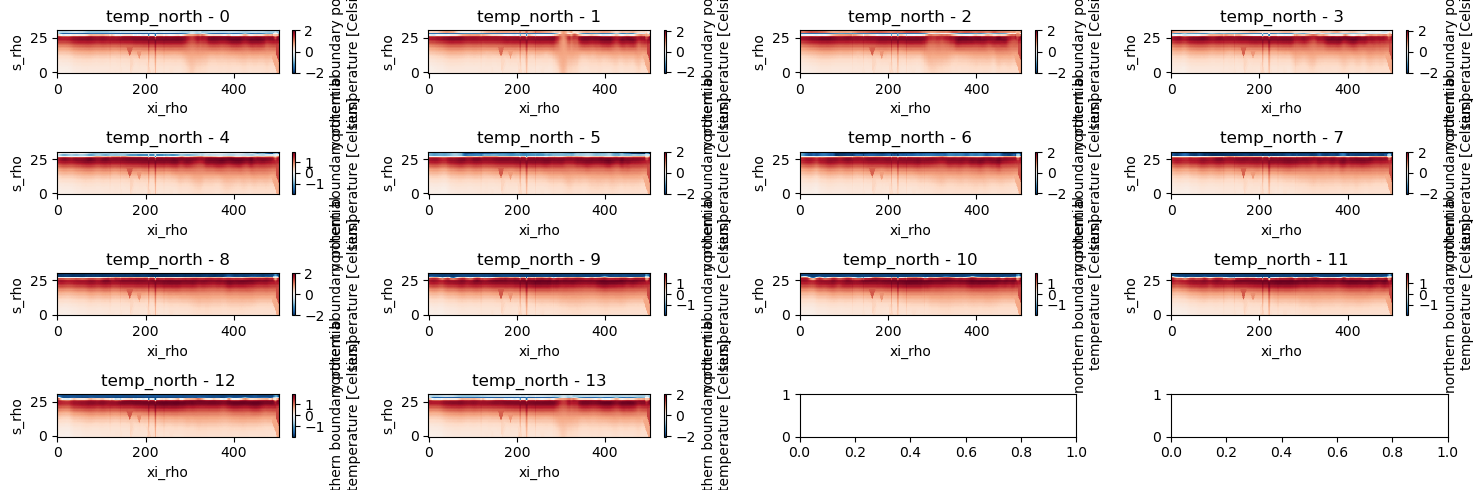

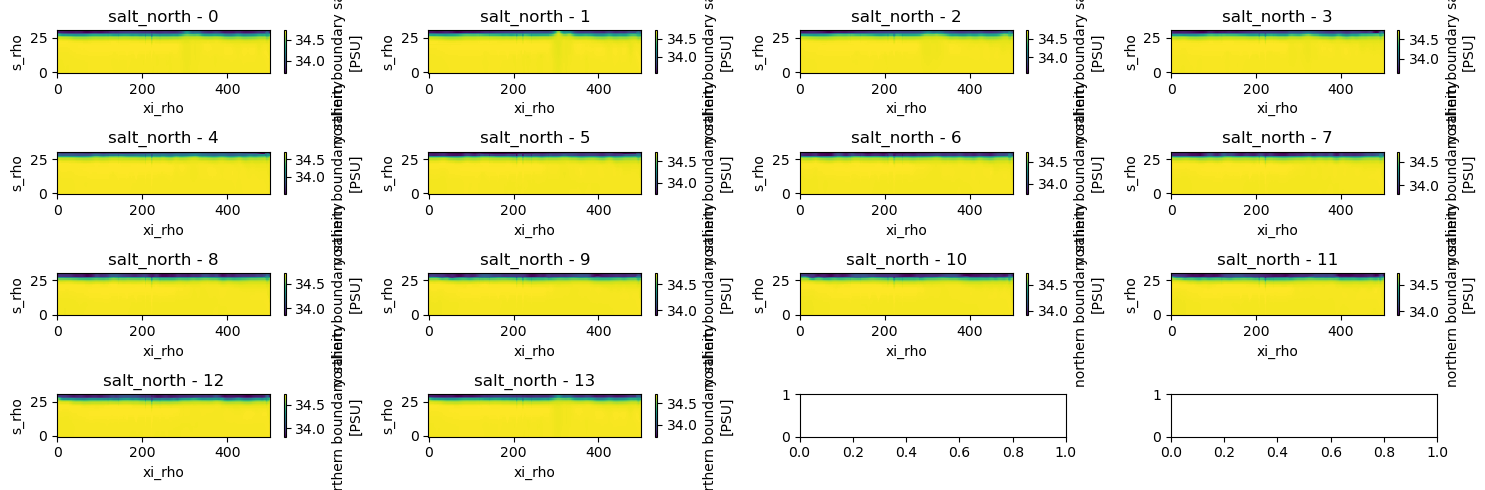

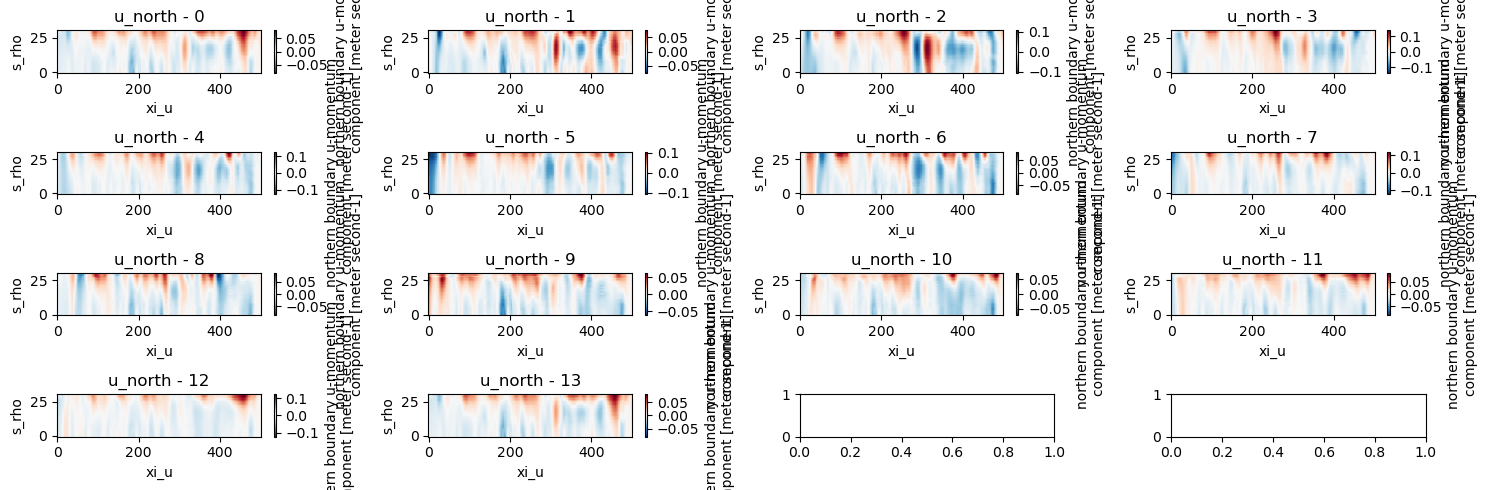

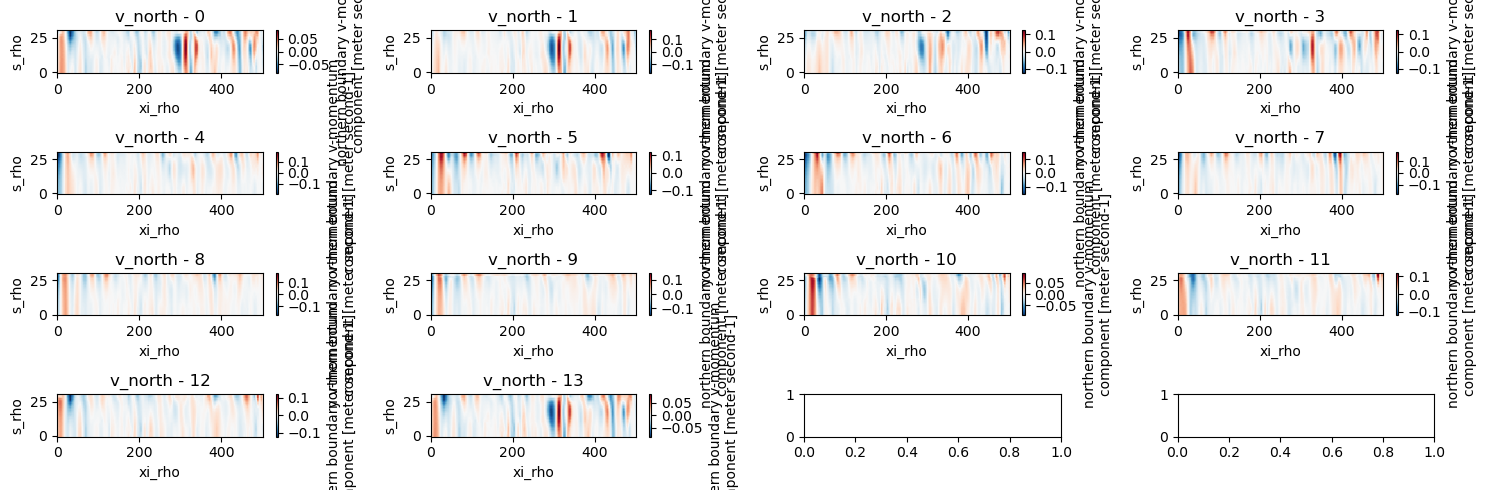

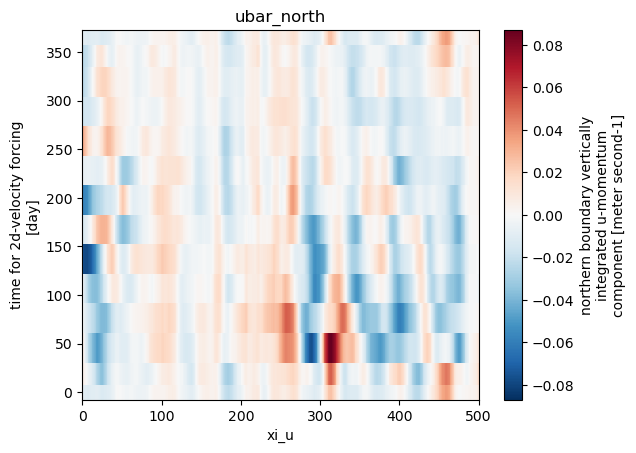

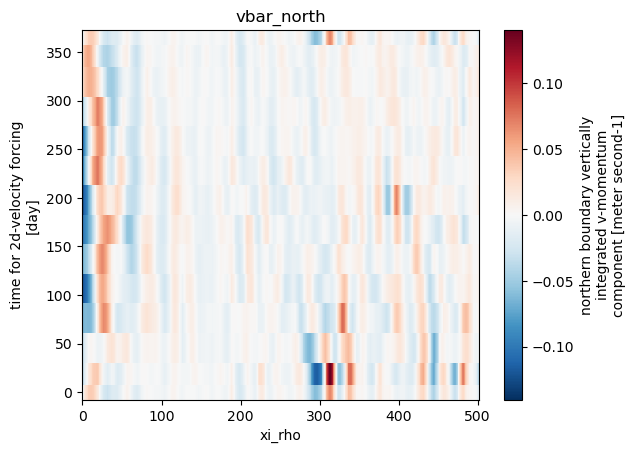

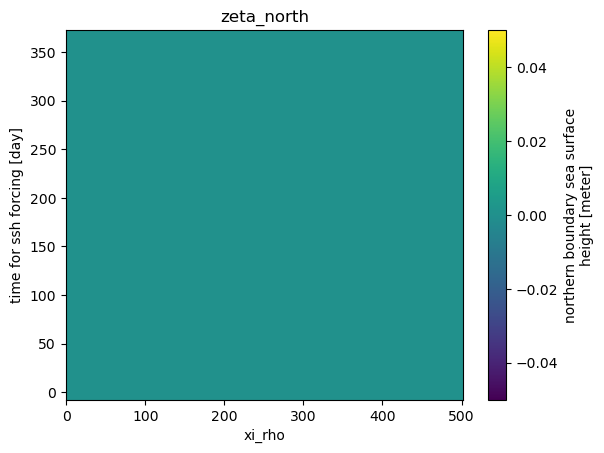

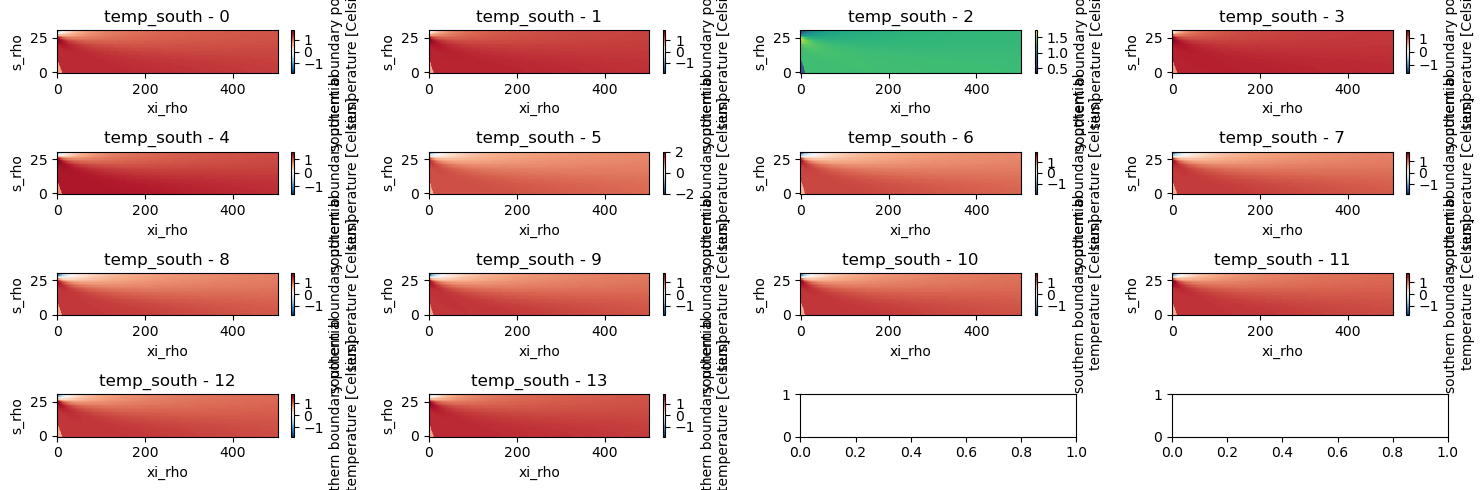

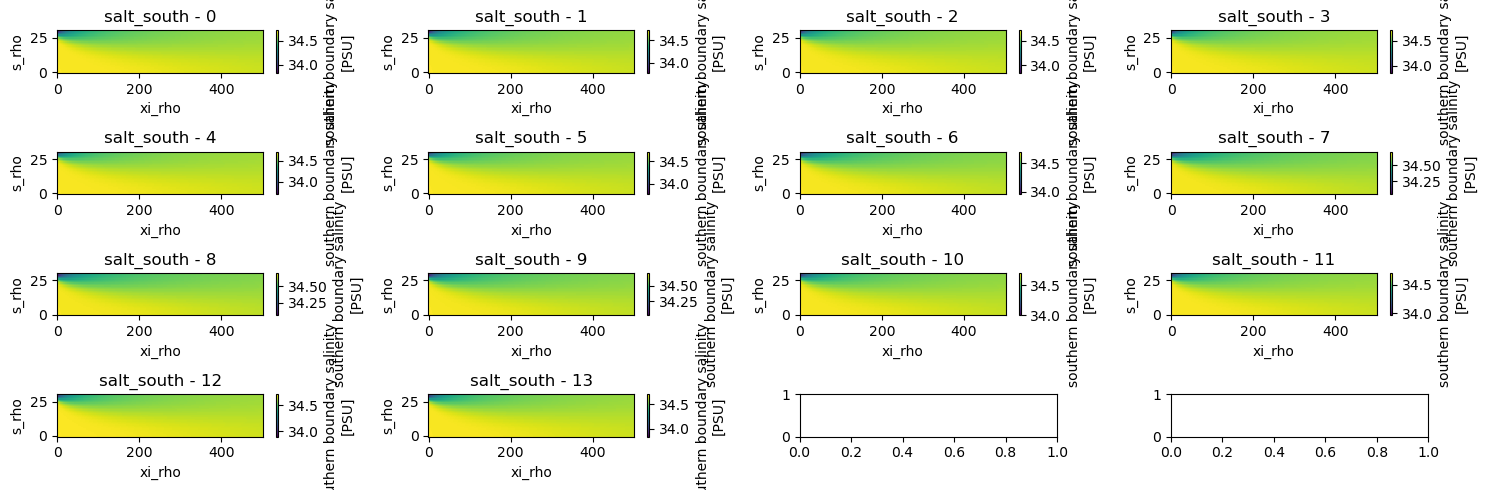

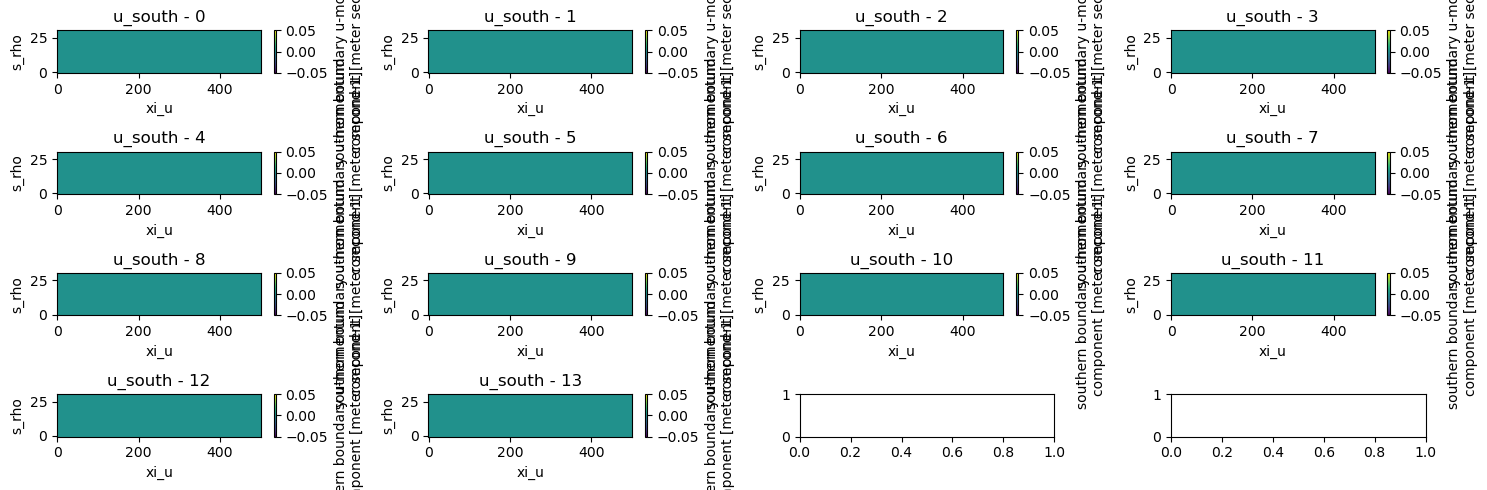

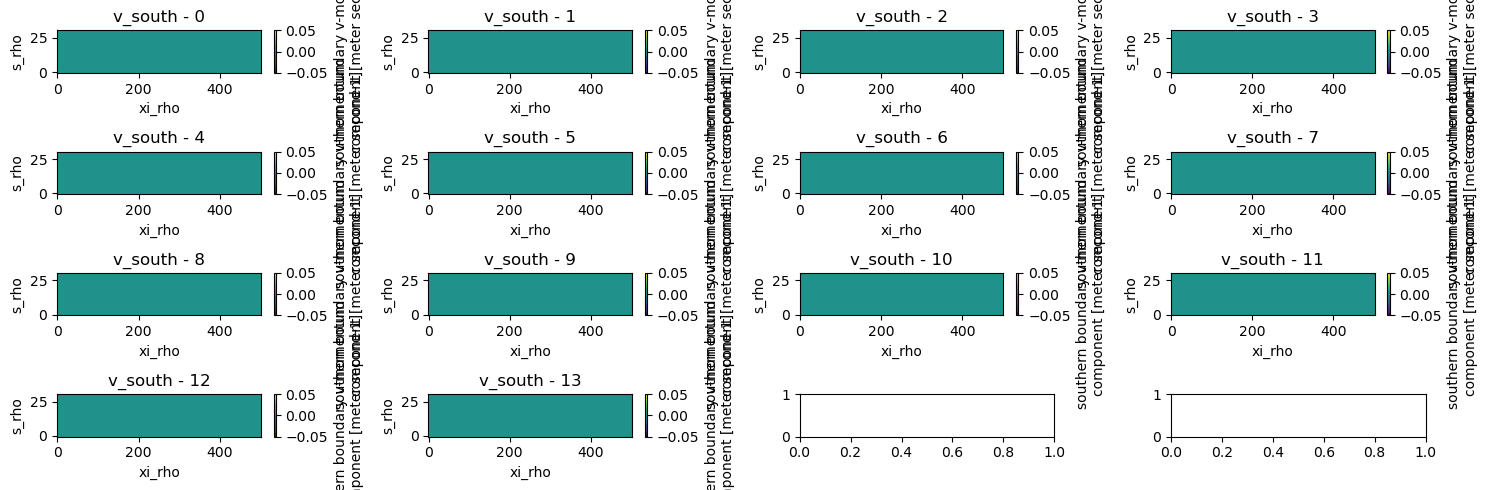

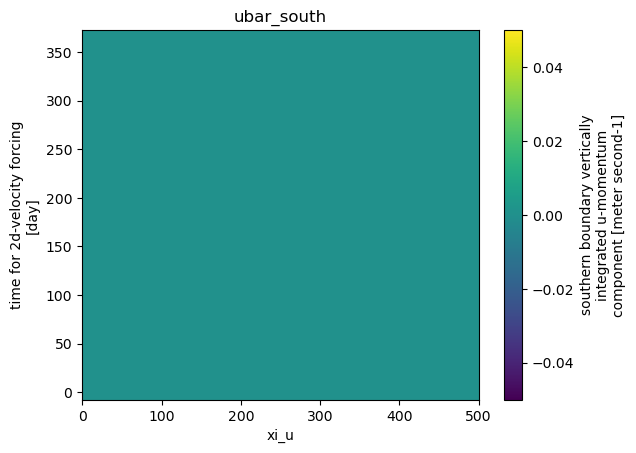

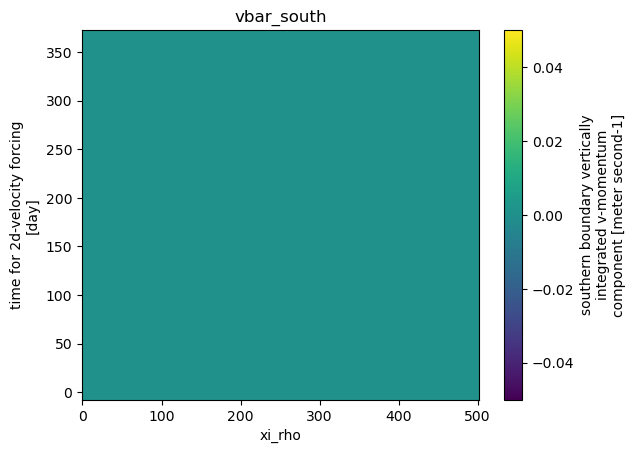

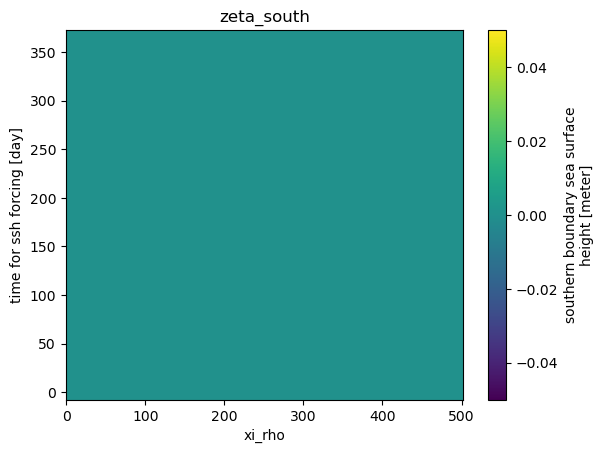

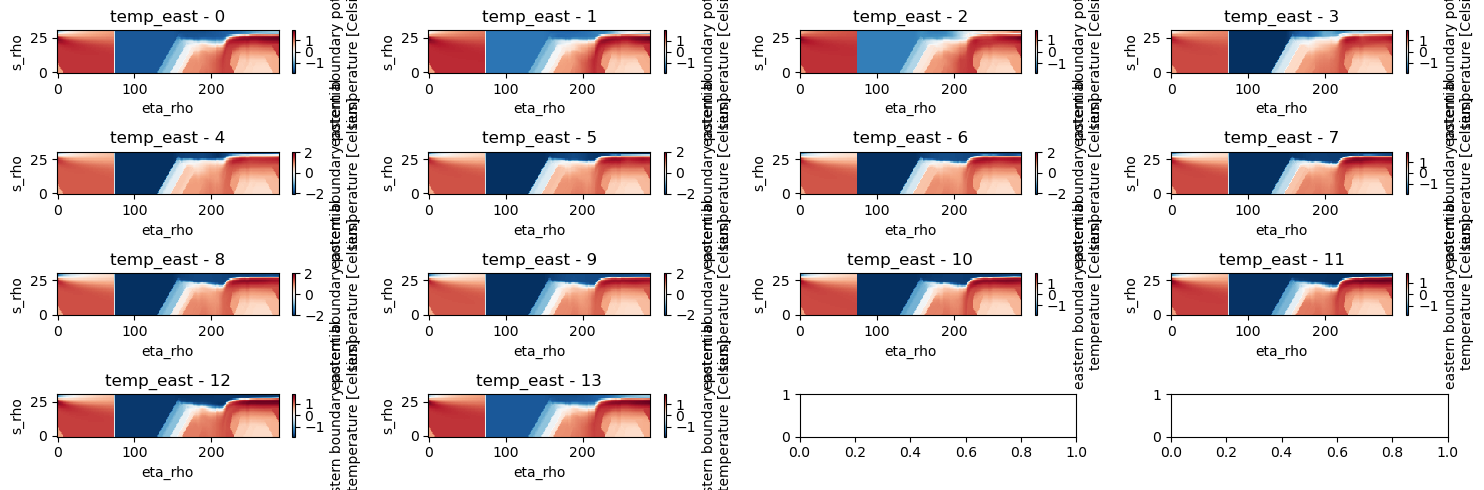

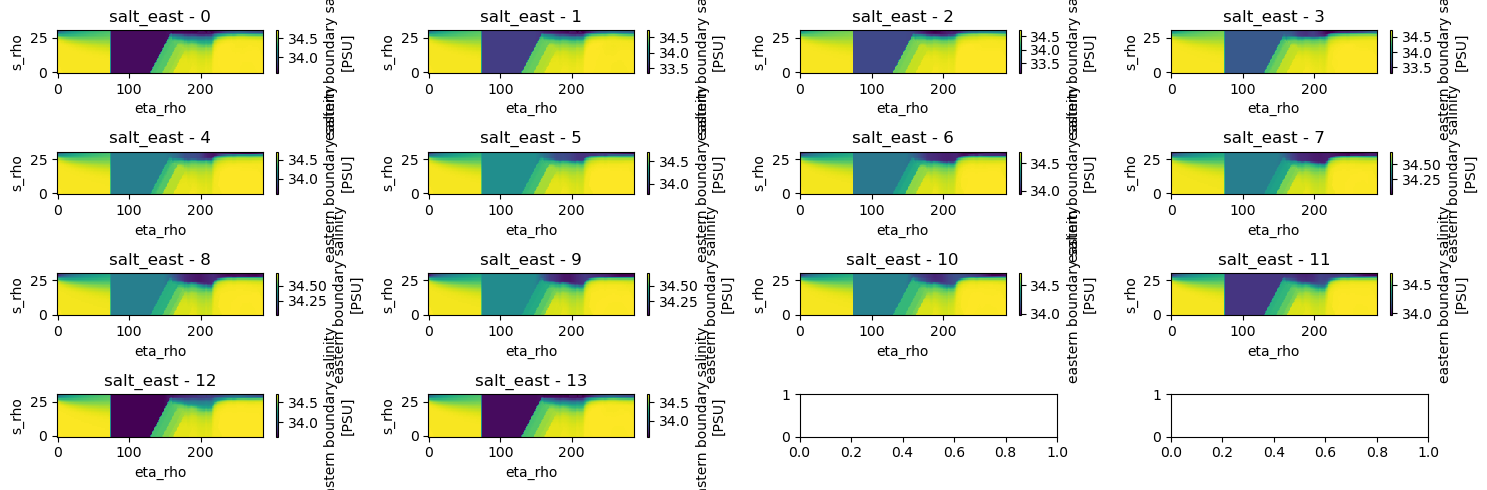

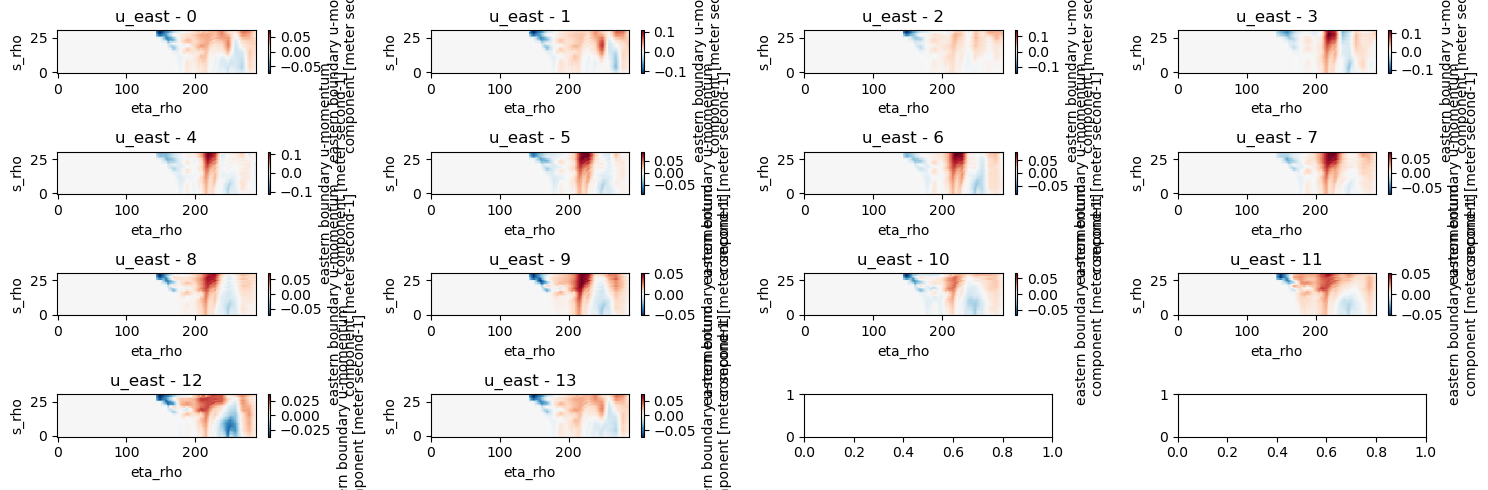

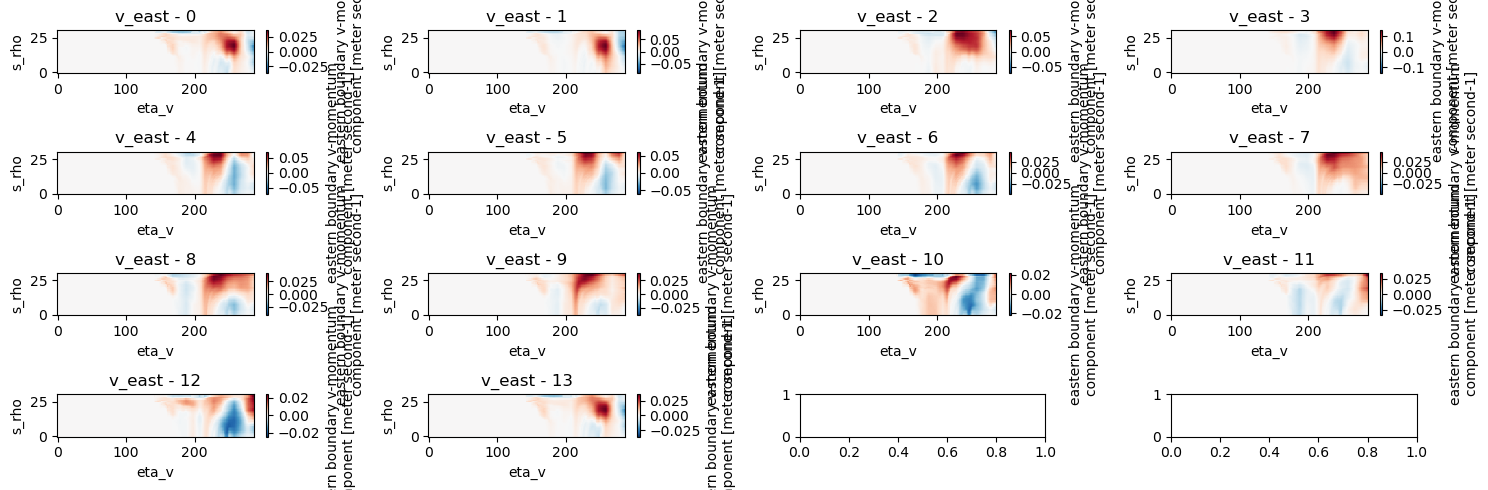

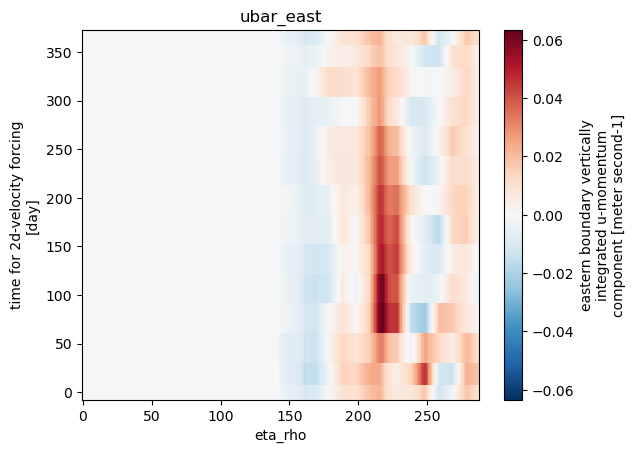

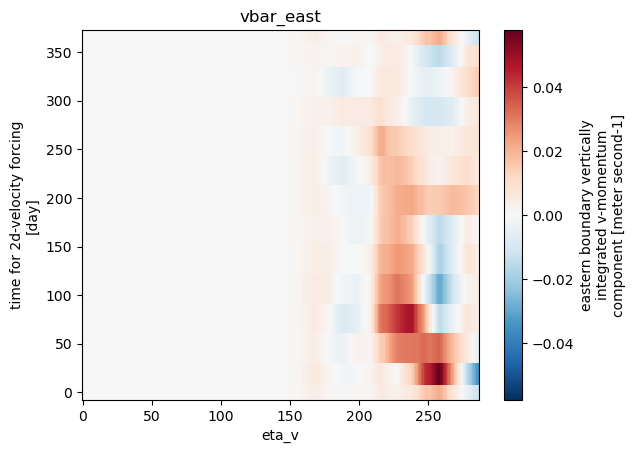

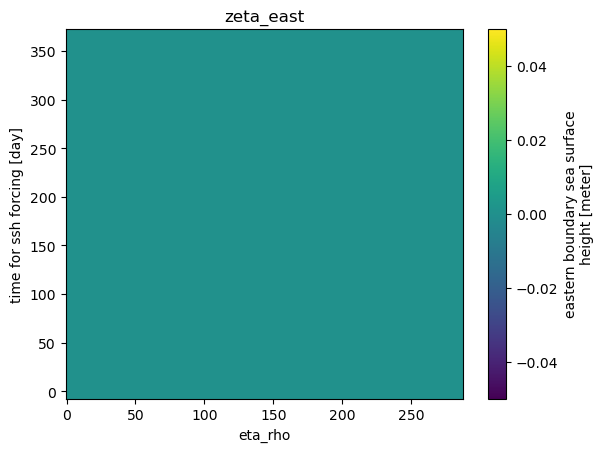

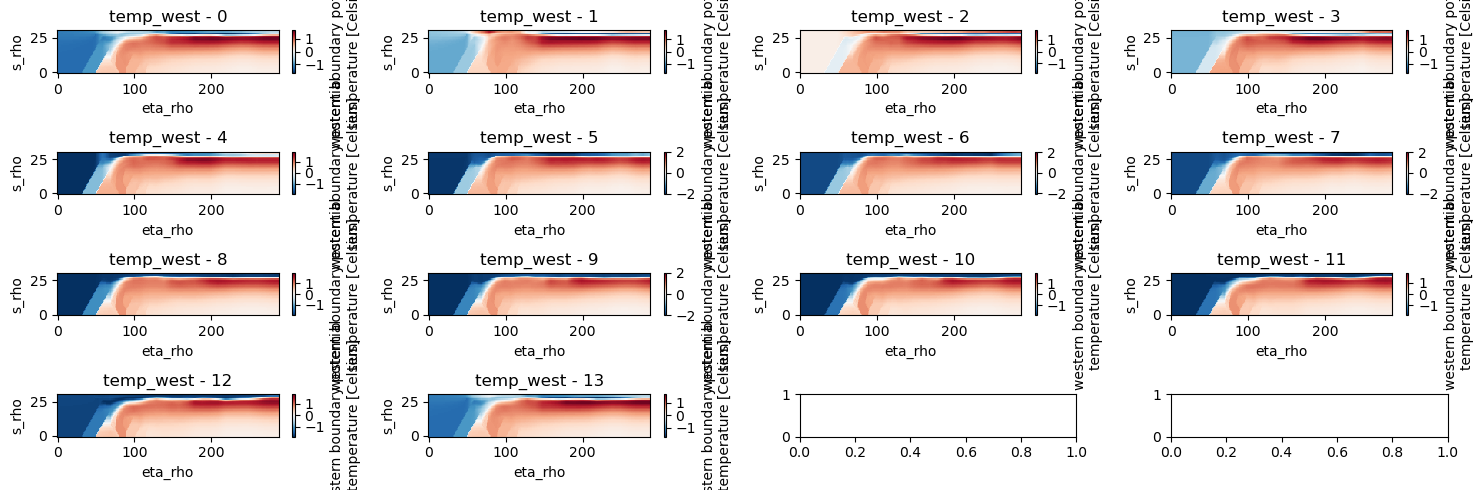

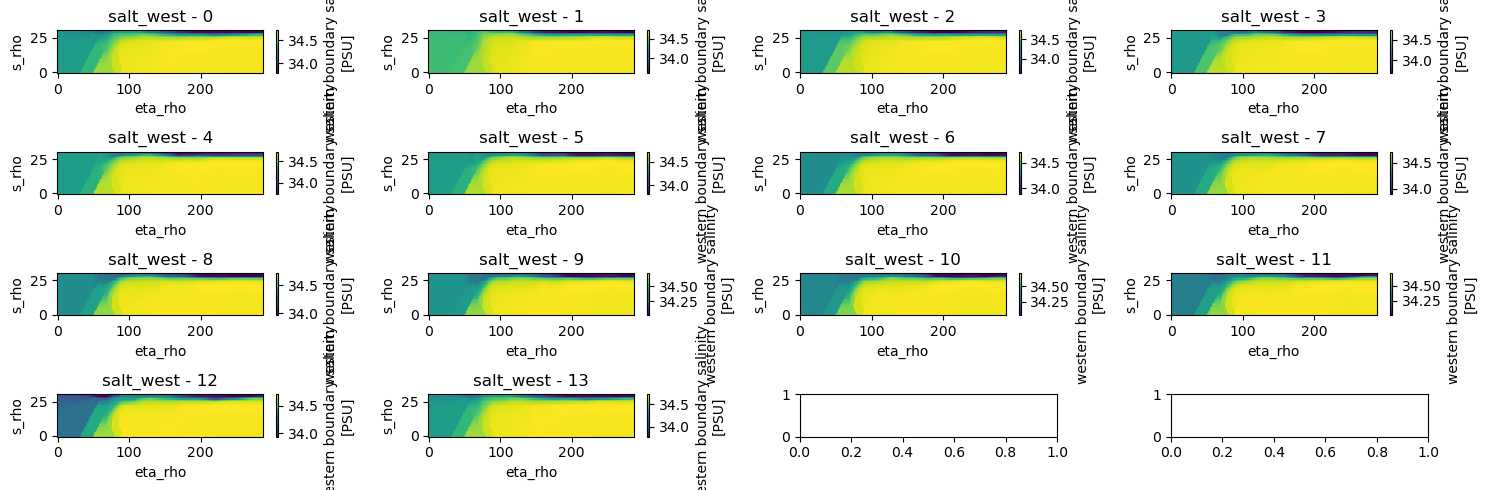

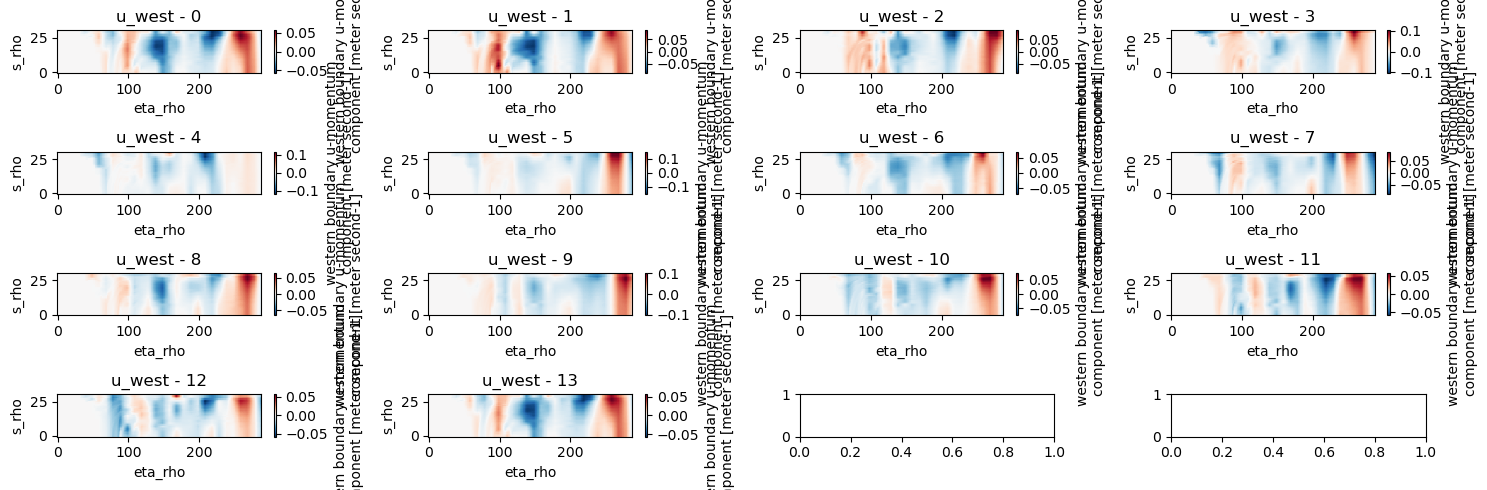

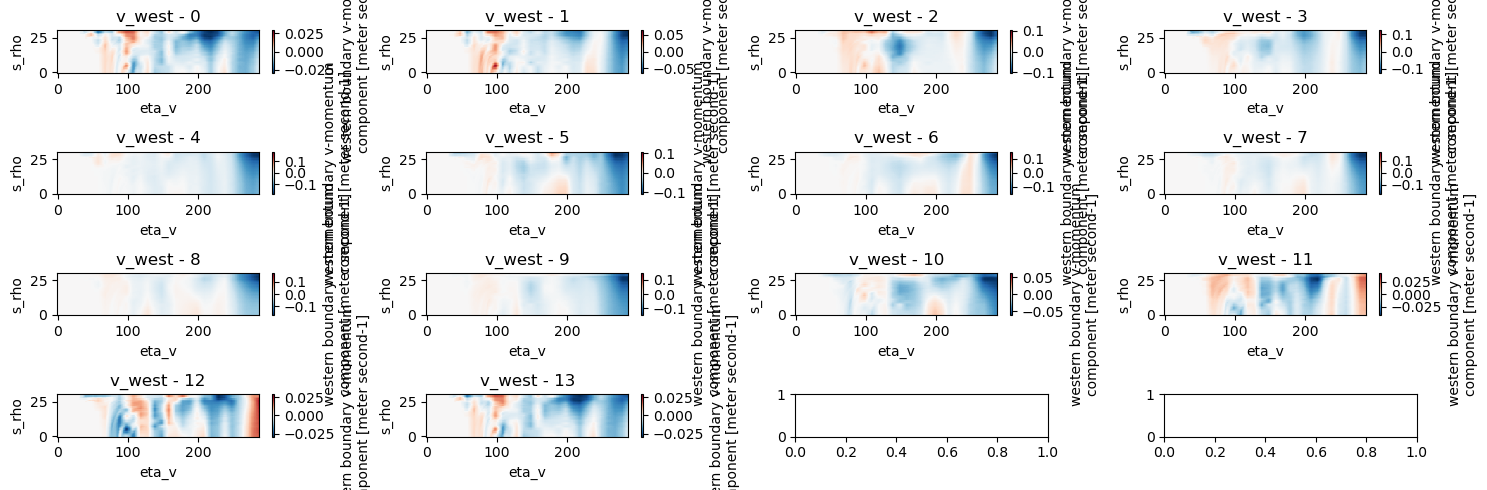

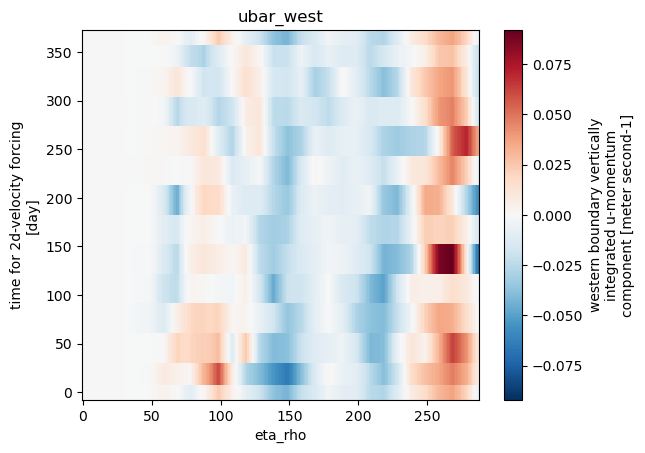

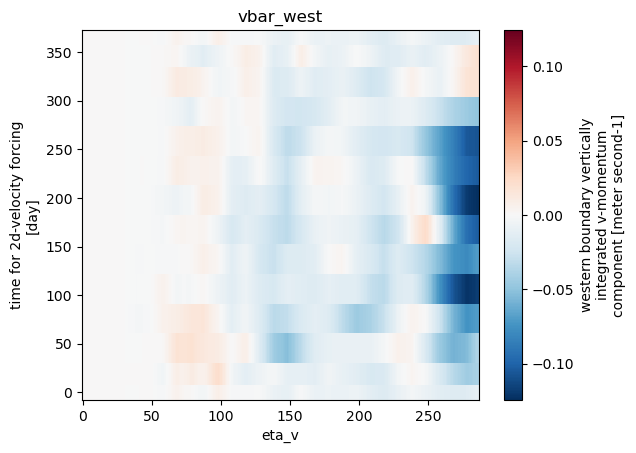

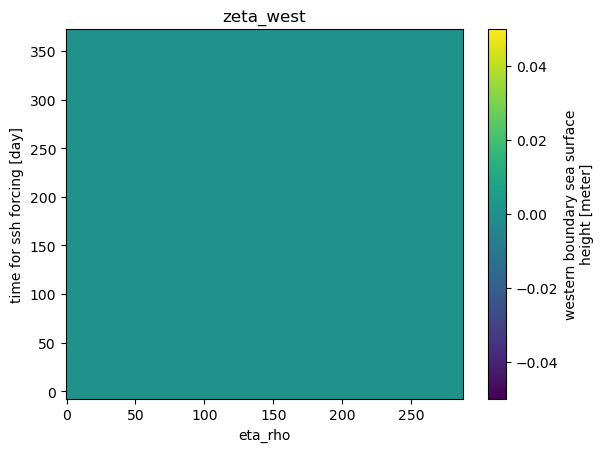

In [11]:

# Iterate over all variables in the dataset
for var_name in frc.data_vars:
    var = frc[var_name]
    
    # Check for NaNs and Infs
    if var.isnull().any():
        print(f"Warning: NaNs found in {var_name}")
    if np.isinf(var).any():
        print(f"Warning: Infs found in {var_name}")
    
    # Plot the variable if it ends with _north, _south, _east, or _west
    if var_name.endswith(('_north', '_south', '_east', '_west')):
        if len(var.shape) == 3:
            fig, axes = plt.subplots(ncols=4,nrows=4, figsize=(15, 5))
            for i in range(var.shape[0]):
                ax = axes[i // 4, i % 4] if var.shape[0] > 1 else axes
                var[i,:,:].plot.pcolormesh(ax=ax)
                ax.set_title(f"{var_name} - {i}")
            plt.tight_layout()
            plt.show()
        else:
            var.plot.pcolormesh()
            plt.title(var_name)
            plt.show()

In [12]:
# # frc.to_netcdf(out_file, unlimited_dims="bry_time")
# frc.to_netcdf(out_file, unlimited_dims=["zeta_time", "temp_time", "v2d_time", "v3d_time","salt_time"])

In [13]:
# sorted(filelist)


In [14]:
# import glob
# ConCatAllFiles = True

# if ConCatAllFiles:
#     # fileList = os.path.join(data_dir,'proc',run+'_[1-2][0-9][0-9][0-9]_bry.nc')
#     # print(fileList)
#     # ds = xr.open_mfdataset(fileList)
    
#     chunks = {'ocean_time':1}
#     filelist = sorted(glob.glob(os.path.join(data_dir,'proc',run+'_[1-2][0-9][0-9][0-9]_bry.nc')))
#     print(filelist)
#     # outName = xr.open_mfdataset(filelist,chunks, data_vars='minimal', compat='override', coords='minimal', parallel=True, join='right') 
#     ds = xr.open_dataset('/g/data/jk72/deg581/amery-hires-setup/data/proc/amery_v2km_2022_bry.nc')
   

In [15]:
# ds = xr.open_mfdataset('/g/data/jk72/deg581/amery-hires-setup/data/proc/amery_v2km_200*_bry.nc',
#     combine='by_coords',
#     coords='minimal',
#     compat='override'
# )

In [16]:
# import xarray as xr
# import numpy as np

# # Your ROMS boundary files
# file_paths = [
#     "/g/data/jk72/deg581/amery-hires-setup/data/proc/amery_v2km_1992_bry.nc",
#     "/g/data/jk72/deg581/amery-hires-setup/data/proc/amery_v2km_1993_bry.nc",
#     "/g/data/jk72/deg581/amery-hires-setup/data/proc/amery_v2km_1994_bry.nc",
#     # ... etc ...
#     # "/g/data/jk72/deg581/amery-hires-setup/data/proc/amery_v2km_2023_bry.nc",
# ]

# # Helper: unify all time-dim variables to a single time coord, e.g., "time"
# def unify_time_dims(ds, target_time_name="bry_time"):
#     # Identify all dimensions that look like time
#     time_dims = [dim for dim in ds.dims if dim.endswith("_time")]

#     # Use the first time coordinate as the reference
#     ref_time_dim = time_dims[0]
#     ref_time = ds[ref_time_dim]

#     # Drop all time-like coords and variables except the reference
#     for td in time_dims:
#         if td != ref_time_dim:
#             if td in ds.coords:
#                 ds = ds.drop_vars(td)
#             if td in ds.variables:
#                 ds = ds.drop_vars(td)

#     # Rename all dimensions in data_vars
#     for var in ds.data_vars:
#         for td in time_dims:
#             if td in ds[var].dims:
#                 ds[var] = ds[var].rename({td: target_time_name})

#     # Drop original reference time dim if it was a coordinate
#     if ref_time_dim != target_time_name and ref_time_dim in ds.coords:
#         ds = ds.drop_vars(ref_time_dim)
#         print('dropping ',ref_time_dim)
        

#     # Assign the unified time coordinate
#     # ds = ds.assign_coords({target_time_name: ref_time})

#     return ds


# # Load and unify time dimensions in each dataset
# datasets = []
# for path in file_paths:
#     ds = xr.open_dataset(path, decode_times=True)
#     unified = unify_time_dims(ds, target_time_name="bry_time")
#     datasets.append(unified)

# # Concatenate along the unified time dimension
# combined = xr.concat(datasets, dim="bry_time")

# # Save to NetCDF with the time dimension as unlimited
# combined.to_netcdf(
#     "amery_v2km_1992-2023_bry_merged.nc",
#     unlimited_dims="bry_time",
#     format="NETCDF4"
# )

# print("✅ Merged ROMS boundary file written as 'amery_v2km_1992-2023_bry_merged.nc'")


In [17]:
# for var in combined.variables:
#     print(f"{var}: {combined[var].dtype}")
    
# for coord in combined.coords:
#     print(f"{coord}: {combined[coord].dtype}")

# for k, v in combined.attrs.items():
#     print(f"{k}: {type(v)}")

In [18]:
# combined

In [19]:
# # Force all lazy-loaded variables into memory
# combined.load()

# # Make a fully independent deep copy to avoid backend conflicts
# combined = combined.copy(deep=True)

# # Save with modern NetCDF4 format
# combined.to_netcdf("/g/data/jk72/deg581/amery-hires-setup/data/proc/bry_merged_cleaned.nc")

In [20]:
# #Check southern boundary
# plt.plot(angle_south[0,0,:])
# plt.show()
# plt.quiver(uvel.LONGITUDE_T,theta.LATITUDE_T,uvel.UVEL.isel(TIME=0,DEPTH_T=5),vvel.VVEL.isel(TIME=0,DEPTH_T=0),scale=2.5)
# plt.axis((88,92,-70,-60))
# plt.quiver(grd.lon_rho[0,:],grd.lat_rho[0,:],u_south_unrot[0,30,:],v_south_unrot[0,30,:],scale=2.5)
# plt.quiver(grd.lon_rho[0,:],grd.lat_rho[0,:],-v_south[0,30,:],u_south_rho[0,30,:],color='r',scale=2.5)
# plt.show()
# plt.plot(np.rad2deg(grd.angle[0,:]))
# np.rad2deg(angle_south[0,0,:])

In [21]:
# #Check east boundary
                                                                                        
# plt.quiver(uvel.LONGITUDE_T,theta.LATITUDE_T,uvel.UVEL.isel(TIME=0,DEPTH_T=5),vvel.VVEL.isel(TIME=0,DEPTH_T=0),scale=2.5)
# plt.axis((62,92,-61,-57))
# plt.quiver(grd.lon_rho[:,-1],grd.lat_rho[:,-1],u_east_unrot[0,30,:],v_east_unrot[0,30,:],scale=2.5)
# plt.quiver(grd.lon_rho[:,-1],grd.lat_rho[:,-1],-v_east_rho[0,30,:],u_east[0,30,:],color='r',scale=2.5)
# plt.show()
# plt.plot(np.rad2deg(grd.angle[:,-1]))
# plt.show()
# plt.quiver(u_east[0,30,:],v_east_rho[0,30,:],color='r',scale=2.5)


In [22]:
# #Check north boundary (remember that north is the model defined north - not my geographic north)
                                                                                        
# plt.quiver(uvel.LONGITUDE_T,theta.LATITUDE_T,uvel.UVEL.isel(TIME=0,DEPTH_T=5),vvel.VVEL.isel(TIME=0,DEPTH_T=0),scale=2.5)
# plt.axis((55,70,-67,-56))
# plt.quiver(grd.lon_rho[-1,:],grd.lat_rho[-1,:],u_north_unrot[0,30,:],v_north_unrot[0,30,:],scale=2.5)
# plt.quiver(grd.lon_rho[-1,:],grd.lat_rho[-1,:],u_north_rho[0,30,:],v_north[0,30,:],color='r',scale=2.5)
# plt.show()
# plt.plot(np.rad2deg(grd.angle[-1,:]))
# plt.show()
# plt.quiver(u_north_rho[0,30,:],v_north[0,30,:],color='r',scale=2.5)



In [23]:
# #Check west boundary (remember that west is the model defined north - not my geographic north)
                                                                                        
# plt.quiver(uvel.LONGITUDE_T,theta.LATITUDE_T,uvel.UVEL.isel(TIME=0,DEPTH_T=5),vvel.VVEL.isel(TIME=0,DEPTH_T=0),scale=2.5)
# # plt.axis((62,92,-61,-57))
# plt.quiver(grd.lon_rho[:,0],grd.lat_rho[:,0],u_west_unrot[0,30,:],v_west_unrot[0,30,:],scale=2.5)
# plt.quiver(grd.lon_rho[:,0],grd.lat_rho[:,0],u_west[0,30,:],v_west_rho[0,30,:],color='r',scale=2.5)
# plt.show()
# plt.plot(np.rad2deg(grd.angle[:,0]))
# plt.show()
# plt.quiver(u_west[0,30,:],v_west_rho[0,30,:],color='r',scale=2.5)


In [24]:
# print(u_south.shape)
# print(u_east.shape)
# print(v_east.shape)